In [1]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image

from ip_adapter.ip_adapter_faceid import IPAdapterFaceID

base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"
vae_model_path = "stabilityai/sd-vae-ft-mse"
ip_ckpt = "ip-adapter-faceid_sd15.bin"
device = "cuda:1"

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)
vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float16)
pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float16,
    scheduler=noise_scheduler,
    vae=vae,
    feature_extractor=None,
    safety_checker=None
)

/home/user/miniconda/envs/neg/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [2]:
ip_model = IPAdapterFaceID(pipe, ip_ckpt, device)

/home/user/miniconda/envs/neg/lib/python3.10/site-packages/diffusers/models/lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer", "1.0.0", deprecation_message)


In [10]:
import numpy as np
faceid = torch.tensor(np.array(torch.load("faceid_embeds_database.pt", map_location="cpu")[:1].detach().cpu()))

In [11]:
faceid = faceid / faceid.norm()

In [12]:
faceid.norm()

tensor(1.)

In [ ]:
import cv2
import random
# generate image
prompt = "photo of a man in red clothes in a garden" 
negative_prompt = "monochrome, lowres, bad anatomy, worst quality, low quality, blurry"


images = ip_model.generate(
    prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid, num_samples=1, width=512, height=512, num_inference_steps=30, seed=random.randint(0, 1000000)
)

  0%|          | 0/30 [00:00<?, ?it/s]

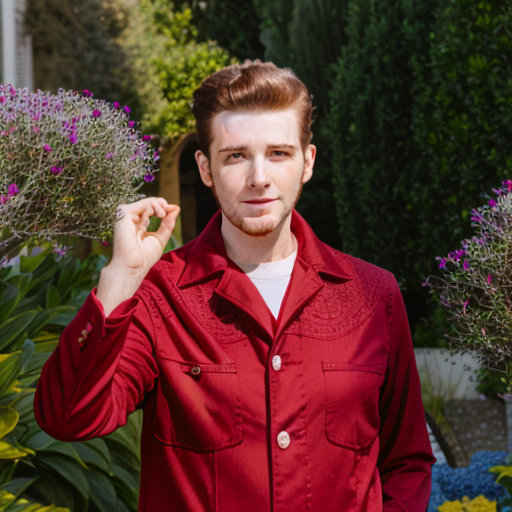

In [14]:
images[0].save("inverted.png")
images[0]

In [15]:
from deepface import DeepFace

In [ ]:
DeepFace.verify(img1_path='val/022668.jpg', img2_path="inverted.png") 

{'verified': True,
 'distance': 0.470467,
 'threshold': 0.68,
 'confidence': 72.83,
 'model': 'VGG-Face',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 0,
   'y': 0,
   'w': 159,
   'h': 159,
   'left_eye': (105, 61),
   'right_eye': (38, 60)},
  'img2': {'x': 198,
   'y': 108,
   'w': 121,
   'h': 121,
   'left_eye': None,
   'right_eye': None}},
 'time': 0.34}

: 